# UAV Data Analysis

Exploratory analysis of the UAV cascade training tiles (5-channel stacks
`[R, G, B, nDSM_cm, Coarse_Class]`, 12-class masks). Same figure style and class
palette as the aerial analysis and the results plots.

In [1]:
import os, re, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from cycler import cycler

# --- Reproducibility ---
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed(42)

# --- Plot style + unified palette (identical to evaluate.py / train_uav.py) ---
# First 8 are the tab10 colors of the aerial stage; 9-12 cover the UAV-only classes.
PALETTE_HEX = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
               "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
               "#bcbd22", "#17becf", "#ffd700", "#008080"]
BG, PANEL, FG, GRID = "#1a1a2e", "#16213e", "#ebebf5", "#464664"

NUM_CLASSES = 12
MASK_CMAP = ListedColormap(PALETTE_HEX)
plot_palette = sns.color_palette(PALETTE_HEX)

plt.rcParams.update({
    "figure.figsize":    (12, 6),
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "savefig.facecolor": BG,
    "text.color":        FG,
    "axes.labelcolor":   FG,
    "axes.edgecolor":    FG,
    "xtick.color":       FG,
    "ytick.color":       FG,
    "grid.color":        GRID,
    "grid.alpha":        0.35,
    "axes.titlesize":    18,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.prop_cycle":   cycler(color=PALETTE_HEX),
})
sns.set_palette(PALETTE_HEX)

CLASS_NAMES = {1: "Building", 2: "Greenhouse", 3: "Street", 4: "Car",
               5: "Pavement", 6: "Trees", 7: "Hedge", 8: "Bush",
               9: "Garden", 10: "Gravel", 11: "Acre", 12: "Mowed_Grass"}
CLASS_IDS = list(range(1, 13))
CLASS_ORDER = [CLASS_NAMES[c] for c in CLASS_IDS]

# On-disk channels: 0=Red, 1=Green, 2=Blue, 3=nDSM_cm, 4=Coarse_Class.
CONT_IDX = [0, 1, 2, 3]
CONT_NAMES = ["Red", "Green", "Blue", "nDSM"]
CONT_UNITS = {"Red": "Reflectance (DN)", "Green": "Reflectance (DN)",
              "Blue": "Reflectance (DN)", "nDSM": "Height (m)"}
COARSE_IDX = 4

CONFIG = {"OUTPUT_DIR": "./reports/figures", "PALETTE": PALETTE_HEX}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

## Data loading

File lists for the train / test splits and helpers to read the `.npy` tiles, with
streaming pixel samplers (the full tile set is too large to hold in memory).

In [2]:
DATA_ROOT = "A:/STUDIUM/06_Fruelingssemester26/BA/data/processed/uav_training_data"

def list_split(split):
    imgs = sorted(glob.glob(os.path.join(DATA_ROOT, split, "img_snippets", "*.npy")))
    msks = sorted(glob.glob(os.path.join(DATA_ROOT, split, "mask_snippets", "*.npy")))
    return imgs, msks

def tile_id(path):
    b = os.path.basename(path)
    return re.sub(r"^(img|mask)_", "", b)[:-4]

def load_img(path):
    return np.load(path).astype(np.float32)            # (H, W, 5)

def load_mask(path):
    m = np.load(path)
    return (m[..., 0] if m.ndim == 3 else m).astype(np.int32)   # (H, W), 1..12, 0=nodata

def paired(split):
    imgs, msks = list_split(split)
    mlk = {tile_id(p): p for p in msks}
    return [(i, mlk[tile_id(i)]) for i in imgs if tile_id(i) in mlk]

def valid_mask(img):
    # Invalid pixels are zero-filled in every channel by the snipper.
    return np.any(img[:, :, :4] != 0, axis=-1)

def sample_continuous(splits=("train",), n_tiles=250, per_tile=5000, seed=42):
    """Stack of sampled continuous-channel pixels (nDSM in metres)."""
    rng = np.random.default_rng(seed)
    files = [f for s in splits for f in list_split(s)[0]]
    rng.shuffle(files); files = files[:n_tiles]
    out = []
    for f in files:
        img = load_img(f)
        v = valid_mask(img).ravel()
        cont = img[:, :, CONT_IDX].reshape(-1, 4)[v]
        cont[:, 3] /= 100.0                              # cm -> m
        if cont.shape[0] == 0:
            continue
        idx = rng.choice(cont.shape[0], min(per_tile, cont.shape[0]), replace=False)
        out.append(cont[idx])
    return np.vstack(out)

def sample_by_class(splits=("train",), per_class_per_tile=200, n_tiles=300, seed=42):
    """Per-class sample of continuous-channel pixels as a tidy DataFrame."""
    rng = np.random.default_rng(seed)
    pairs = [p for s in splits for p in paired(s)]
    rng.shuffle(pairs); pairs = pairs[:n_tiles]
    rows = []
    for ip, mp in pairs:
        img = load_img(ip); m = load_mask(mp)
        cont = img[:, :, CONT_IDX].copy(); cont[:, :, 3] /= 100.0
        for cid in CLASS_IDS:
            rr, cc = np.where(m == cid)
            if rr.size == 0:
                continue
            sel = rng.choice(rr.size, min(per_class_per_tile, rr.size), replace=False)
            df = pd.DataFrame(cont[rr[sel], cc[sel], :], columns=CONT_NAMES)
            df["class_id"] = cid; df["class_name"] = CLASS_NAMES[cid]
            rows.append(df)
    out = pd.concat(rows, ignore_index=True)
    out["class_name"] = pd.Categorical(out["class_name"], categories=CLASS_ORDER, ordered=True)
    return out

print("train pairs:", len(paired("train")), "| test pairs:", len(paired("test")))

train pairs: 894 | test pairs: 174


## 1. Dataset inventory and integrity

Tile counts, image-mask pairing, tile shape / dtype and the mask class-ID range
for both splits.

In [3]:
rows = []
for split in ("train", "test"):
    imgs, msks = list_split(split)
    ids_i = {tile_id(p) for p in imgs}
    ids_m = {tile_id(p) for p in msks}
    sample = load_img(imgs[0])
    sample_m = load_mask(msks[0])
    rows.append({
        "split": split,
        "img_tiles": len(imgs),
        "mask_tiles": len(msks),
        "unpaired": len(ids_i ^ ids_m),
        "img_shape": str(sample.shape),
        "img_dtype": str(np.load(imgs[0]).dtype),
        "mask_classes": f"{int(sample_m.min())}..{int(sample_m.max())}",
    })
inventory = pd.DataFrame(rows)
display(inventory)

,split,img_tiles,mask_tiles,unpaired,img_shape,img_dtype,mask_classes
0,train,894,894,0,"(1024, 1024, 5)",uint16,10..12
1,test,174,174,0,"(1024, 1024, 5)",uint16,3..12


## 2. Visual sanity check

One random tile shown as RGB, nDSM, the coarse-context class channel and the
ground-truth mask, to confirm alignment and label sanity.

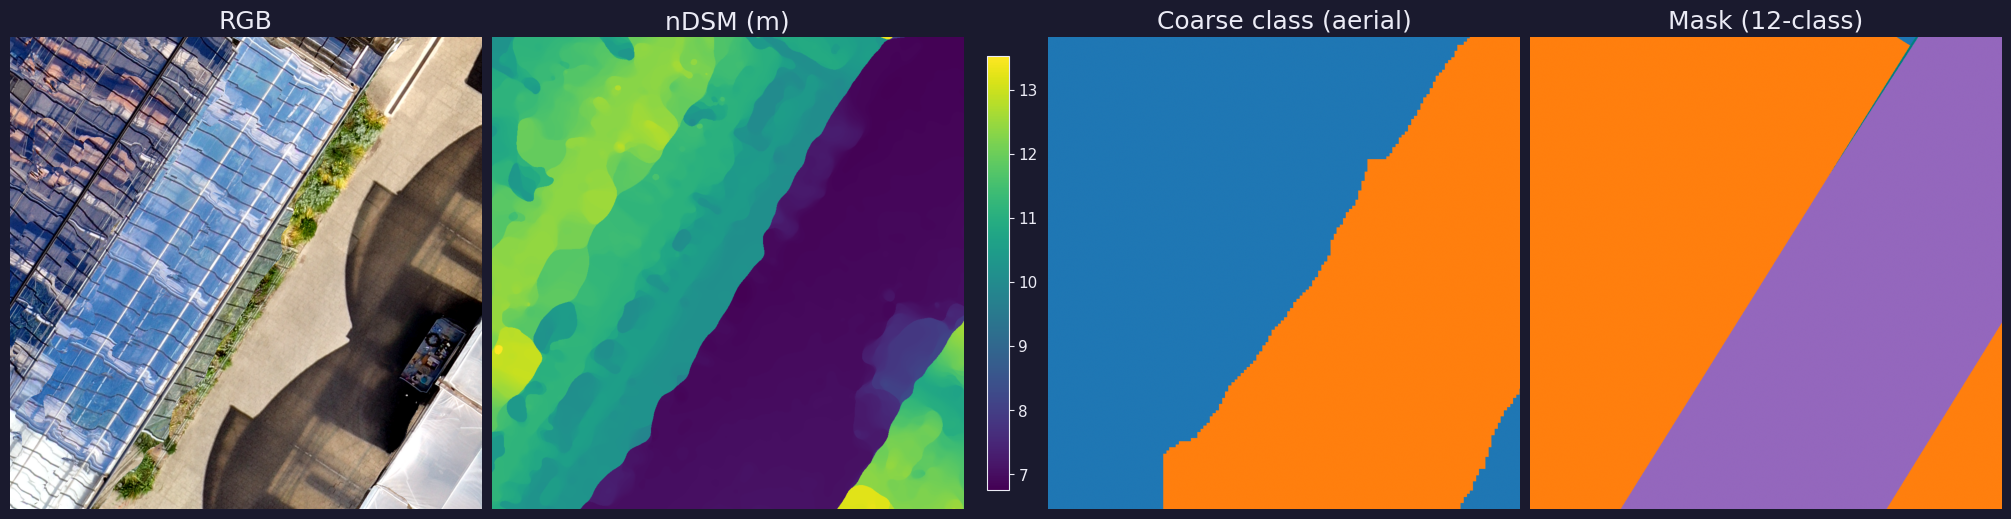

In [4]:
rng = np.random.default_rng(7)
pairs_tr = paired("train")
ip, mp = pairs_tr[rng.integers(len(pairs_tr))]
img = load_img(ip); m = load_mask(mp)

def stretch(b):
    b = b.astype(np.float32); lo, hi = np.percentile(b, [2, 98])
    return np.clip((b - lo) / (hi - lo + 1e-6), 0, 1)

rgb = np.stack([stretch(img[:, :, c]) for c in range(3)], axis=-1)
ndsm_m = img[:, :, 3] / 100.0
coarse = np.ma.masked_equal(img[:, :, COARSE_IDX], 0)
mask_disp = np.ma.masked_equal(m, 0)

fig, ax = plt.subplots(1, 4, figsize=(20, 5.5), constrained_layout=True)
ax[0].imshow(rgb);                                              ax[0].set_title("RGB")
h = ax[1].imshow(ndsm_m, cmap="viridis");                       ax[1].set_title("nDSM (m)")
fig.colorbar(h, ax=ax[1], shrink=0.8)
ax[2].imshow(coarse, cmap=ListedColormap(PALETTE_HEX[:8]), vmin=1, vmax=8)
ax[2].set_title("Coarse class (aerial)")
ax[3].imshow(mask_disp, cmap=MASK_CMAP, vmin=1, vmax=12);       ax[3].set_title("Mask (12-class)")
for a in ax: a.axis("off")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "image_sanity_check.png"), bbox_inches="tight", dpi=150)
plt.show()

## 3. Channel descriptive statistics

Summary statistics and value distributions (histograms with median, boxplots) of
the four continuous input channels, from a streamed pixel sample.

,channel,mean,std,min,p50,max
0,Red,125.783997,63.987999,0.00,134.00,255.00
1,Green,144.324997,58.688000,0.00,156.00,255.00
2,Blue,97.819000,59.528999,0.00,85.00,255.00
3,nDSM,10.513000,5.196000,1.87,7.92,34.93


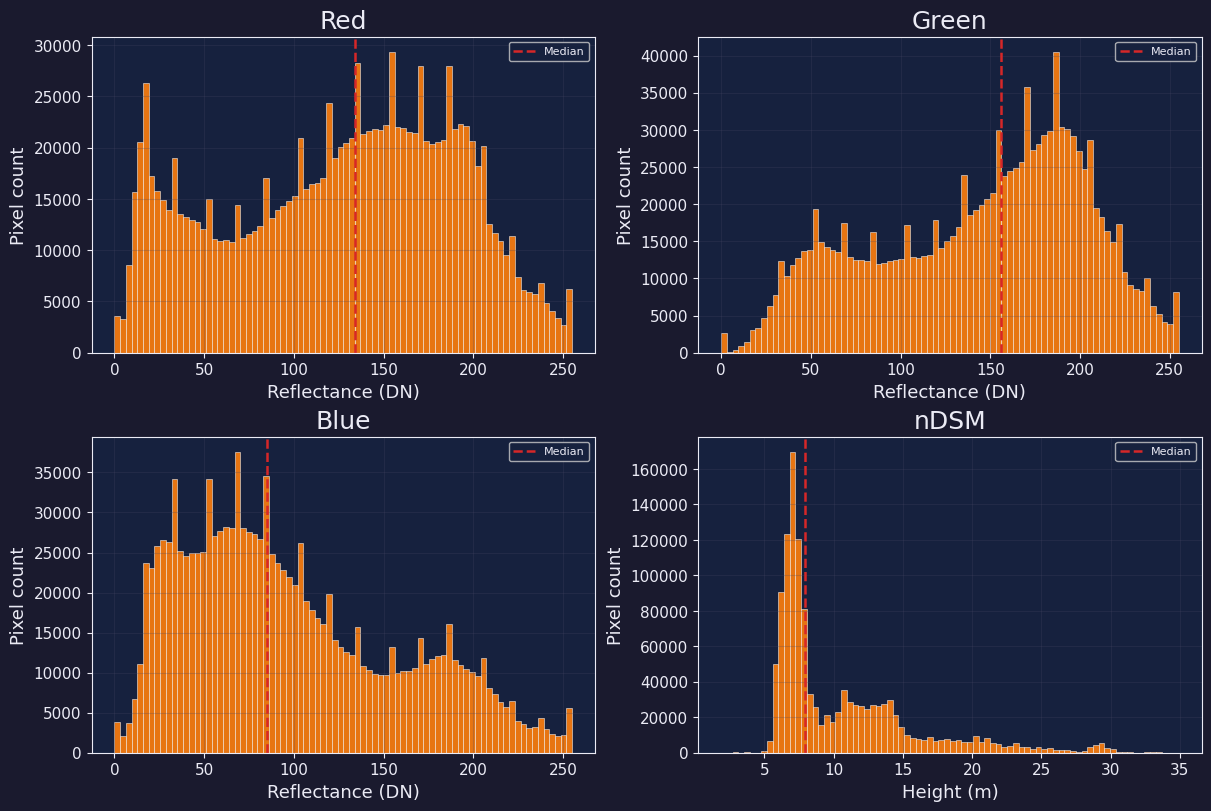

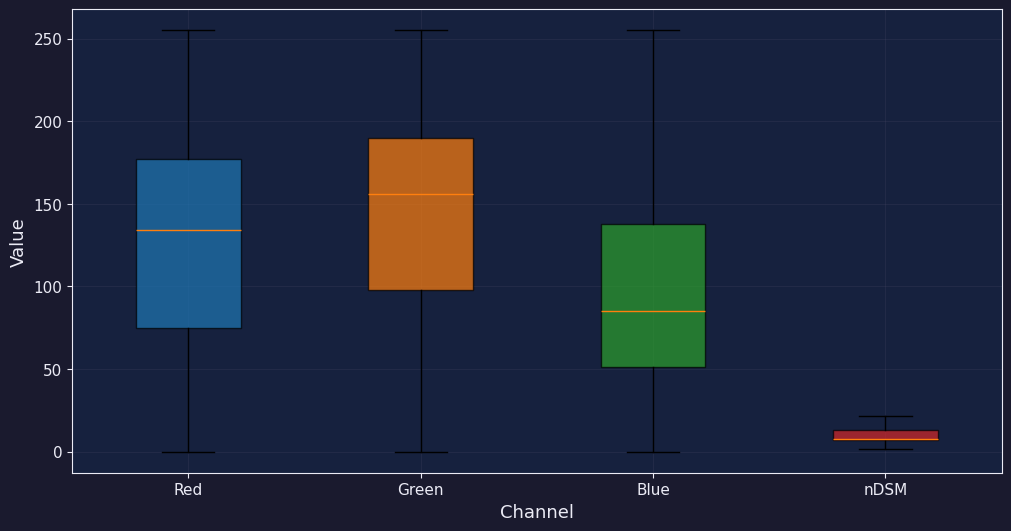

In [5]:
S = sample_continuous(splits=("train",), n_tiles=250, per_tile=5000)
stats = pd.DataFrame({
    "channel": CONT_NAMES,
    "mean": S.mean(0).round(3), "std": S.std(0).round(3),
    "min": S.min(0).round(3), "p50": np.percentile(S, 50, axis=0).round(3),
    "max": S.max(0).round(3),
})
display(stats)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
hist_color, median_color = PALETTE_HEX[1], PALETTE_HEX[3]
for i, ax in enumerate(axes.ravel()):
    vals = S[:, i]
    ax.hist(vals, bins=80, color=hist_color, alpha=0.9, edgecolor="white", linewidth=0.4)
    ax.axvline(np.median(vals), color=median_color, ls="--", lw=1.8, label="Median")
    ax.set_xlabel(CONT_UNITS[CONT_NAMES[i]]); ax.set_ylabel("Pixel count")
    ax.set_title(CONT_NAMES[i]); ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.25)
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "channel_histograms.png"), bbox_inches="tight", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
bp = ax.boxplot([S[:, i] for i in range(4)], patch_artist=True, tick_labels=CONT_NAMES, showfliers=False)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(PALETTE_HEX[i]); patch.set_alpha(0.7)
ax.set_xlabel("Channel"); ax.set_ylabel("Value"); ax.grid(True, alpha=0.25)
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "channel_boxplots.png"), bbox_inches="tight", dpi=150)
plt.show()

## 4. Label distribution and class imbalance

Global pixel count per class across all tiles, rare-class flags, and the
distribution of the coarse-context (aerial 8-class) channel.

,class_id,class_name,pixels,pct
0,1,Building,139149723,12.426600
1,2,Greenhouse,40824603,3.645792
2,3,Street,78498037,7.010174
3,4,Car,5483234,0.489674
4,5,Pavement,62197814,5.554502
5,6,Trees,351955222,31.430941
6,7,Hedge,13710175,1.224371
7,8,Bush,25276934,2.257326
8,9,Garden,71635858,6.397355
9,10,Gravel,36518890,3.261276


Rare classes (<1%): Car (0.49%)


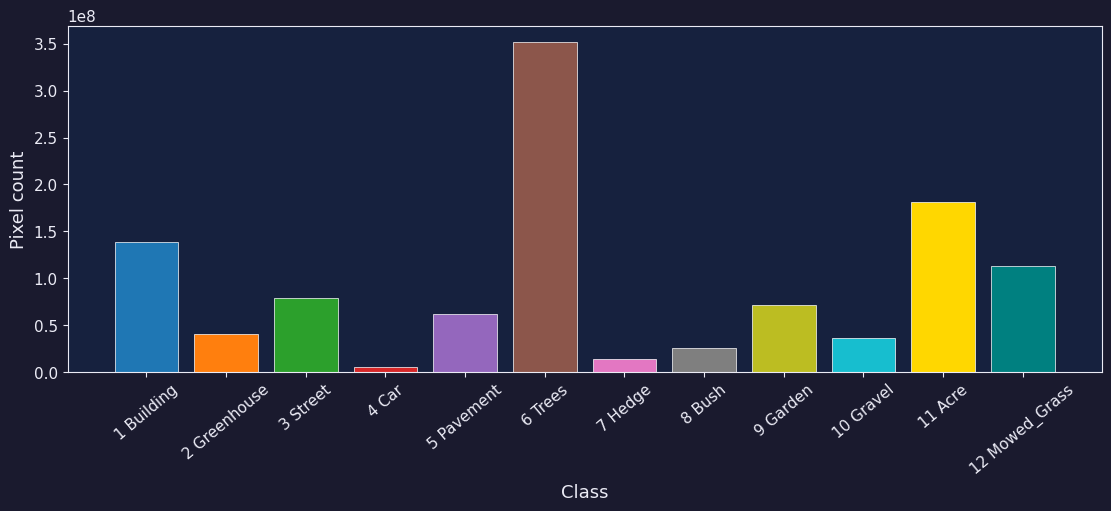

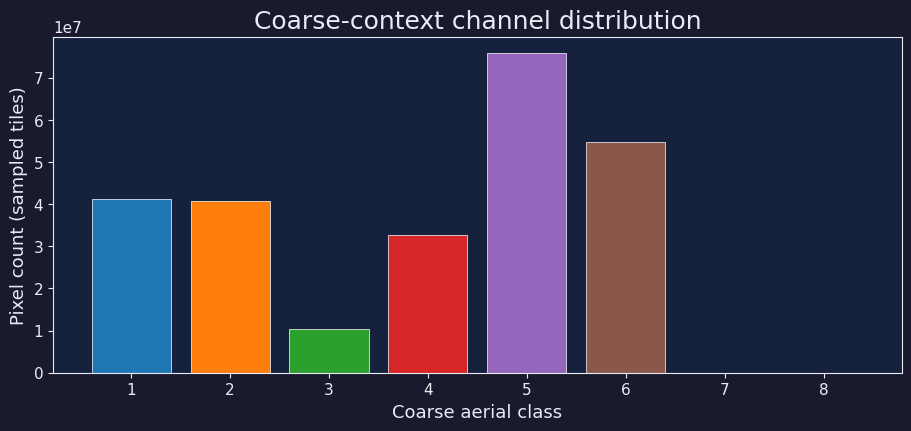

In [6]:
counts = np.zeros(13, dtype=np.int64)
for split in ("train", "test"):
    for _, mp in paired(split):
        m = load_mask(mp)
        u, c = np.unique(m, return_counts=True)
        for k, v in zip(u, c):
            if 0 <= k <= 12: counts[k] += v
total = counts[1:].sum()
global_df = pd.DataFrame({"class_id": CLASS_IDS, "class_name": CLASS_ORDER,
                          "pixels": counts[1:], "pct": 100 * counts[1:] / max(total, 1)})
display(global_df)
rare = global_df[global_df["pct"] < 1.0]
print("Rare classes (<1%):", ", ".join(f"{r.class_name} ({r.pct:.2f}%)" for r in rare.itertuples()) or "none")

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.bar([f"{c} {CLASS_NAMES[c]}" for c in CLASS_IDS], global_df["pixels"],
       color=[PALETTE_HEX[c - 1] for c in CLASS_IDS], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Class"); ax.set_ylabel("Pixel count"); ax.tick_params(axis="x", rotation=40)
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "global_class_counts.png"), bbox_inches="tight", dpi=150)
plt.show()

# Coarse-context channel distribution (aerial classes 1..8, 0 = nodata).
cc = np.zeros(9, dtype=np.int64)
rng = np.random.default_rng(0); files = list_split("train")[0]; rng.shuffle(files)
for f in files[:250]:
    v = load_img(f)[:, :, COARSE_IDX].astype(np.int64).ravel()
    u, c = np.unique(v, return_counts=True)
    for k, val in zip(u, c):
        if 0 <= k <= 8: cc[k] += val
fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
ax.bar([str(i) for i in range(1, 9)], cc[1:], color=[PALETTE_HEX[i] for i in range(8)],
       edgecolor="white", linewidth=0.5)
ax.set_xlabel("Coarse aerial class"); ax.set_ylabel("Pixel count (sampled tiles)")
ax.set_title("Coarse-context channel distribution")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "coarse_context_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

## 5. Channel-class separability

Per-class median of each continuous channel, min-max normalized per channel so
classes with similar spectral/height signatures (hard to separate) stand out.

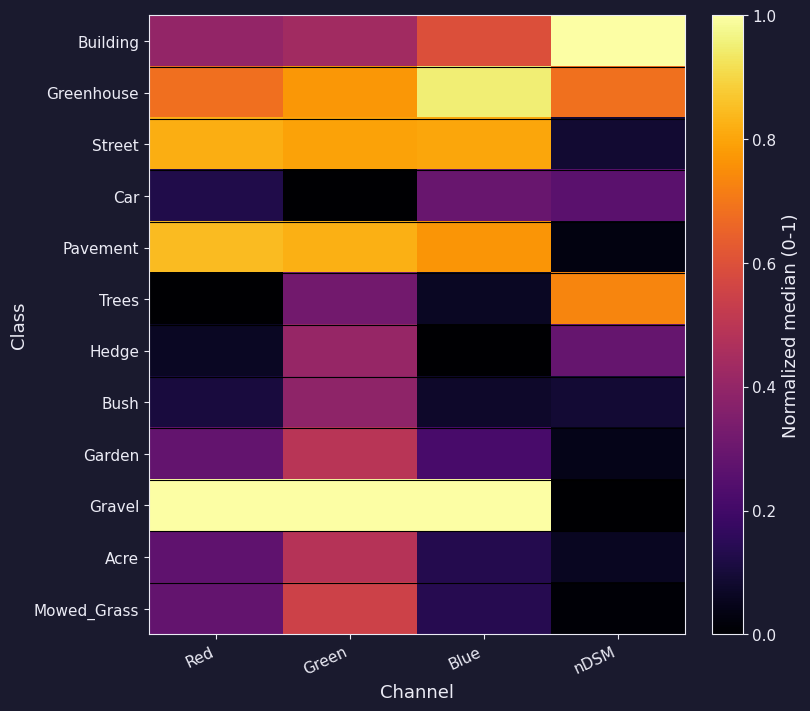

In [7]:
pix = sample_by_class(splits=("train",), per_class_per_tile=200, n_tiles=300)
med = pix.groupby("class_name", observed=False)[CONT_NAMES].median().reindex(CLASS_ORDER)
med_norm = ((med - med.min()) / (med.max() - med.min())).fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
im = ax.imshow(med_norm.values, aspect="auto", cmap="inferno", vmin=0, vmax=1)
ax.set_xlabel("Channel"); ax.set_ylabel("Class")
ax.set_xticks(range(len(CONT_NAMES))); ax.set_xticklabels(CONT_NAMES, rotation=25, ha="right")
ax.set_yticks(range(len(CLASS_ORDER))); ax.set_yticklabels(CLASS_ORDER)
for i in range(len(CLASS_ORDER) - 1): ax.axhline(i + 0.5, color="black", lw=0.8)
cbar = fig.colorbar(im, ax=ax); cbar.set_label("Normalized median (0-1)")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "class_vs_pixel_median_heatmap_normalized.png"), bbox_inches="tight", dpi=150)
plt.show()

## 6. Channel correlation and redundancy

Pearson correlation between the four continuous channels on a sampled pixel set,
to reveal redundant signals (e.g. the visible bands).

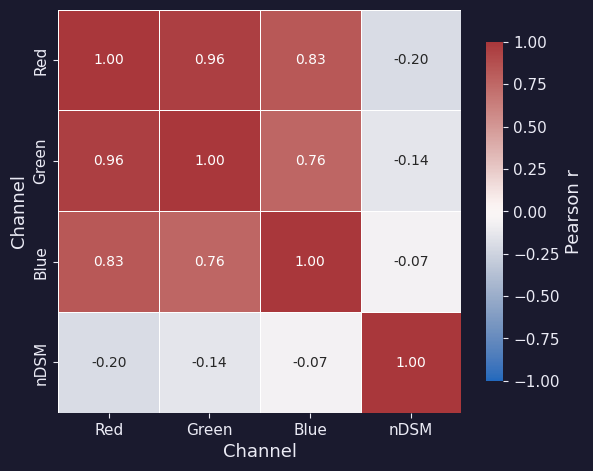

In [8]:
dfc = pd.DataFrame(S, columns=CONT_NAMES)
corr = dfc.corr(method="pearson")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson r"}, ax=ax)
ax.set_xlabel("Channel"); ax.set_ylabel("Channel")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "correlation_pearson.png"), bbox_inches="tight", dpi=150)
plt.show()
corr.to_csv(os.path.join(CONFIG["OUTPUT_DIR"], "correlation_pearson.csv"))

## 7. Feature importance (Random Forest proxy)

A pixel-wise Random Forest on the continuous channels as a fast, model-agnostic
proxy for how separable the classes are from RGB + nDSM alone, with tree-based
importances and a confusion matrix.

train acc=0.654 | test acc=0.590


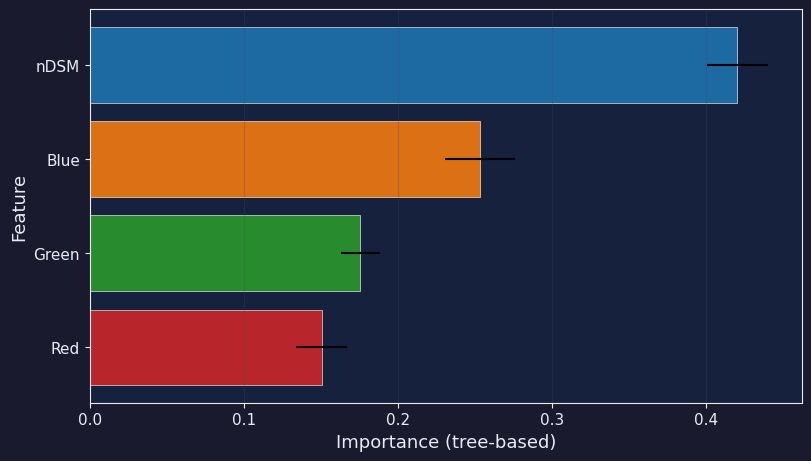

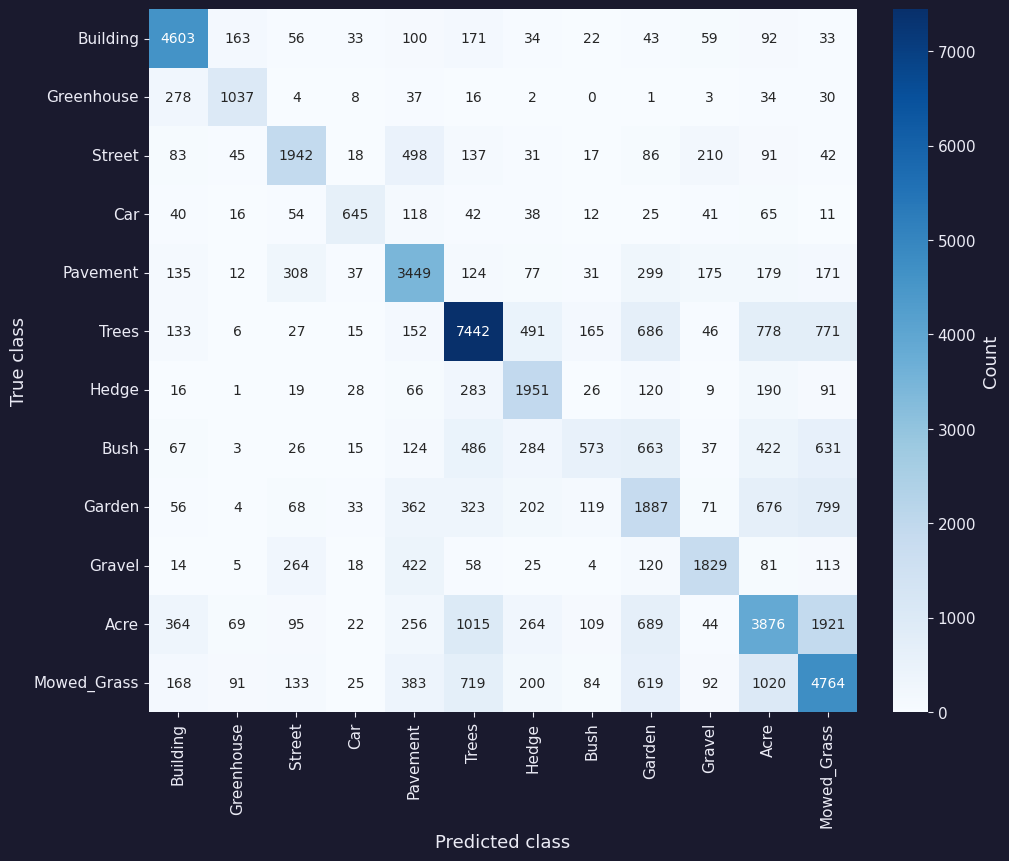

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X = pix[CONT_NAMES].values.astype(np.float32)
y = pix["class_id"].values.astype(np.int32)
ok = np.isfinite(X).all(axis=1); X, y = X[ok], y[ok]
labels = sorted(np.unique(y)); names = [CLASS_NAMES[c] for c in labels]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
print(f"train acc={rf.score(Xtr, ytr):.3f} | test acc={rf.score(Xte, yte):.3f}")

fi = pd.DataFrame({"feature": CONT_NAMES, "importance": rf.feature_importances_,
                   "std": np.std([t.feature_importances_ for t in rf.estimators_], axis=0)}
                  ).sort_values("importance", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.barh(fi["feature"], fi["importance"], xerr=fi["std"],
        color=[PALETTE_HEX[i] for i in range(len(fi))], alpha=0.85, edgecolor="white", linewidth=0.5)
ax.invert_yaxis(); ax.set_xlabel("Importance (tree-based)"); ax.set_ylabel("Feature"); ax.grid(True, alpha=0.25, axis="x")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "feature_importance_barplot.png"), bbox_inches="tight", dpi=150)
plt.show()

cm = confusion_matrix(yte, rf.predict(Xte), labels=labels)
fig, ax = plt.subplots(figsize=(10, 8.5), constrained_layout=True)
sns.heatmap(pd.DataFrame(cm, index=names, columns=names), annot=True, fmt="d",
            cmap="Blues", cbar_kws={"label": "Count"}, ax=ax)
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "feature_importance_confusion_matrix.png"), bbox_inches="tight", dpi=150)
plt.show()

## 8. Train/test split quality

Class distribution and channel statistics of the block-checkerboard split,
confirming every class is present in both splits with comparable signal.

,class,train_%,test_%
0,Building,12.22,13.48
1,Greenhouse,3.74,3.17
2,Street,6.46,9.82
3,Car,0.47,0.59
4,Pavement,5.21,7.34
5,Trees,32.62,25.30
6,Hedge,1.18,1.47
7,Bush,1.83,4.43
8,Garden,6.17,7.57
9,Gravel,2.99,4.63


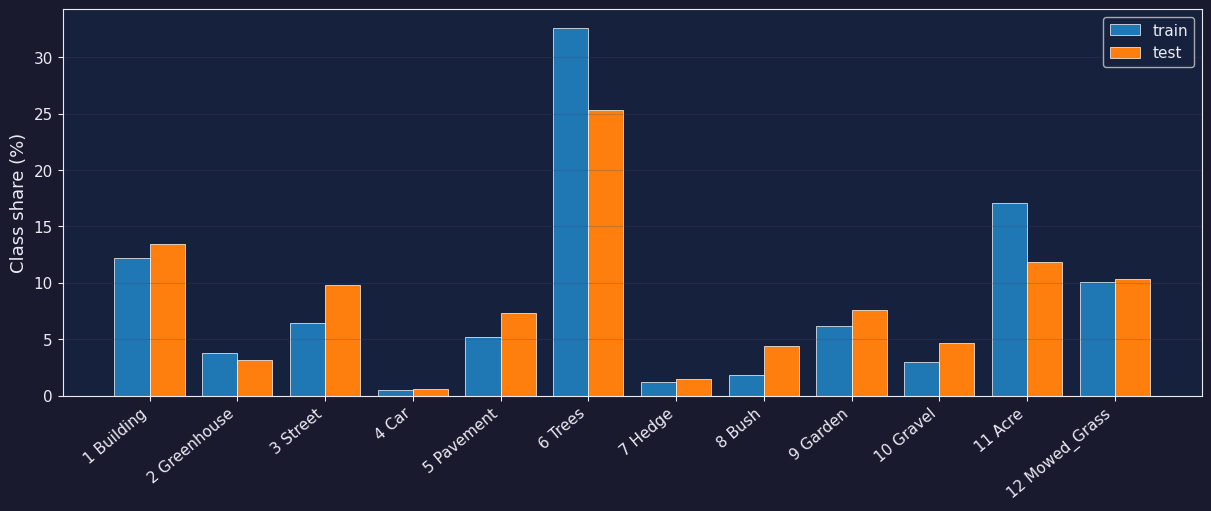

,channel,train_mean,test_mean,train_std,test_std
0,Red,125.779999,133.610001,63.990002,66.050003
1,Green,144.320007,147.710007,58.689999,58.770000
2,Blue,97.820000,109.790001,59.529999,63.610001
3,nDSM,10.510000,10.950000,5.200000,6.380000


In [10]:
def class_share(split):
    counts = np.zeros(13, np.int64)
    for _, mp in paired(split):
        u, c = np.unique(load_mask(mp), return_counts=True)
        for k, v in zip(u, c):
            if 0 <= k <= 12: counts[k] += v
    return 100 * counts[1:] / max(counts[1:].sum(), 1)

shr = pd.DataFrame({"class": CLASS_ORDER, "train_%": class_share("train").round(2),
                    "test_%": class_share("test").round(2)})
display(shr)

x = np.arange(12); w = 0.4
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.bar(x - w/2, shr["train_%"], w, label="train", color=PALETTE_HEX[0], edgecolor="white", linewidth=0.5)
ax.bar(x + w/2, shr["test_%"],  w, label="test",  color=PALETTE_HEX[1], edgecolor="white", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels([f"{c} {CLASS_NAMES[c]}" for c in CLASS_IDS], rotation=40, ha="right")
ax.set_ylabel("Class share (%)"); ax.legend(); ax.grid(True, alpha=0.25, axis="y")
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "split_class_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

st = sample_continuous(("train",)); se = sample_continuous(("test",))
chan_stats = pd.DataFrame({"channel": CONT_NAMES,
                           "train_mean": st.mean(0).round(2), "test_mean": se.mean(0).round(2),
                           "train_std": st.std(0).round(2),  "test_std": se.std(0).round(2)})
display(chan_stats)